# Project 4: Music Popularity Prediction


## Problem Statement

The objectives of this project are to:
1. **Predict** the popularity of a *new*, unreleased song.
2. Minimize the **cross-validated RMSE** for model accuracy.

# Comment

Perfect mention of *new* songs and of minimizing CV-RMSE!  That shows you're thinking about data leakage and performance metrics.

Just a minor tweak: make sure to avoid the word 'accuracy' here. In DS, accuracy is strictly a classification metric. For regression, we want to talk about minimizing error ( thus the RMSE ) or maximizing predictive performance.

## Methodology

* **Data**: Top 200 Weekly (Global) Charts of Spotify in 2020 & 2021
* **Source**: AWS, https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv
* **Methods**:
  * Data cleaning
  * Decision-tree (ML)

## Imports

In [1]:
import pandas as pd
import numpy as np
import re
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import plotly.express as px

## IDA

* Where is the data located, size, do I have access, etc.

In [2]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"

In [3]:
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: JLF08ujB4Lx0mzQkYQrbPN3Ozy8KZ8RWtoDTi0xB9CzBxfhdkdgBwk5vAAJUGcBrA5KO0QM5AGKa3DOGK2bn1azYmmo7HvkR
x-amz-request-id: 5TNVTJD7RA3SG655
Date: Tue, 26 May 2026 13:06:31 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [4]:
!curl -s -O {url}

In [5]:
# Verify the data was loaded
!ls -la

total 740
drwxr-xr-x 1 root root   4096 May 26 13:06 .
drwxr-xr-x 1 root root   4096 May 26 12:50 ..
drwxr-xr-x 4 root root   4096 May 21 13:26 .config
drwxr-xr-x 1 root root   4096 May 21 13:27 sample_data
-rw-r--r-- 1 root root 738124 May 26 13:06 Spotify.csv


In [6]:
# Provides the header / column names
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## EDA

In [7]:
orig_dat = pd.read_csv( url, index_col = 0)
orig_dat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1556 entries, 1 to 1556
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Highest Charting Position  1556 non-null   int64 
 1   Number of Times Charted    1556 non-null   int64 
 2   Week of Highest Charting   1556 non-null   object
 3   Song Name                  1556 non-null   object
 4   Streams                    1556 non-null   object
 5   Artist                     1556 non-null   object
 6   Artist Followers           1556 non-null   object
 7   Song ID                    1556 non-null   object
 8   Genre                      1556 non-null   object
 9   Release Date               1556 non-null   object
 10  Weeks Charted              1556 non-null   object
 11  Popularity                 1556 non-null   object
 12  Danceability               1556 non-null   object
 13  Energy                     1556 non-null   object
 14  Loudness     

In [8]:
# helper functions

def metadata( dataframe ):
  '''Given a dataframe, returns a dataframe of metadata about the dataframe'''
  metadata_df = pd.DataFrame()
  metadata_df["Data_types"] = dataframe.dtypes
  metadata_df["Count"] = len(dataframe)
  metadata_df["Nulls"] = dataframe.isnull().sum()
  metadata_df["Nulls_pct"] = ( metadata_df["Nulls"] / metadata_df["Count"] * 100 ).round(1)
  metadata_df["Memory"] = dataframe.memory_usage( deep = True)
  metadata_df["NUnique"] = dataframe.nunique()
  metadata_df["NUnique_pct"] = (dataframe.nunique() / metadata_df["Count"] * 100).round(1)
  metadata_df = metadata_df.join( dataframe.describe( include = "all" ).transpose() )
  metadata_df = metadata_df.astype( { "count" : int } )
  if dataframe.select_dtypes(include=['number']).shape[1] :
    metadata_df["IRQ"] = metadata_df["75%"] - metadata_df["25%"]
    metadata_df["range"] = metadata_df["max"] - metadata_df["min"]
    metadata_df["sum"] = metadata_df["mean"] * metadata_df["count"]
    metadata_df = (
      metadata_df
      .rename( columns = {
        "25%" : "Q1_25%",
        "50%" : "Q2_median",
        "75%" : "Q3_75%",
        }
      )
    )
  return metadata_df

def cols_to_drop( dataframe ):
  '''Given a dataframe, returns columns that should likely be dropped'''
  md = metadata( dataframe )
  filter = md["Nulls_pct"] >= 40
  return md[ filter ]["Nulls_pct"].to_dict()

def likely_ids( dataframe ):
  '''Given a dataframe, returns a dictionary of likely ID columns'''
  md = metadata( dataframe )
  return md["NUnique_pct"][ md["NUnique_pct"] > 95 ].sort_values( ascending = False )

In [9]:
metadata(orig_dat)

,Data_types,Count,Nulls,Nulls_pct,Memory,NUnique,NUnique_pct,count,unique,top,...,mean,std,min,Q1_25%,Q2_median,Q3_75%,max,IRQ,range,sum
Highest Charting Position,int64,1556,0,0.0,12448,200,12.9,1556,NaN,NaN,...,87.744216,58.147225,1.0,37.0,80.0,137.0,200.0,100.0,199.0,136530.0
Number of Times Charted,int64,1556,0,0.0,12448,75,4.8,1556,NaN,NaN,...,10.66838,16.360546,1.0,1.0,4.0,12.0,142.0,11.0,141.0,16600.0
Week of Highest Charting,object,1556,0,0.0,110476,83,5.3,1556,83,2019-12-27--2020-01-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Song Name,object,1556,0,0.0,107813,1556,100.0,1556,1556,Lover (Remix) [feat. Shawn Mendes],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Streams,object,1556,0,0.0,90353,1556,100.0,1556,1556,"4,595,450",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist,object,1556,0,0.0,98048,716,46.0,1556,716,Taylor Swift,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist Followers,object,1556,0,0.0,87449,600,38.6,1556,600,42227614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Song ID,object,1556,0,0.0,110245,1517,97.5,1556,1517,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,object,1556,0,0.0,136772,395,25.4,1556,395,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Release Date,object,1556,0,0.0,91609,478,30.7,1556,478,2020-01-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
cols_to_drop(orig_dat)

{}

In [11]:
likely_ids(orig_dat)

,NUnique_pct
Song Name,100.0
Streams,100.0
Song ID,97.5
Duration (ms),95.5


# Comment

Exploring the metadata - nice!

### Initial Observations
1. **Incorrect Data Types** - Several variables (`Artist Followers`, `Tempo`, `Streams`, etc) are the incorrect data type.
2. **Missing Data** - The most common data type for many variables (such as `Genre` and `Energy`) are empty but being picked up as "not null".
3. **Longitudinal Data** - `Weeks Charted` is a list with multiple dates, or timestamps, where the song was in the charts.
4. **Shape** - There are 1,556 rows and 22 columns.
5. **Unique Identifier** - There are 2 *actual* unique identifier called `Song ID` and `Song Name`.
6. **Messy String Data** - The variables `Chord` and `Genre` likely contain duplicates separated by delimeters such as the comma (,) and slash (/), among other possibilities not observed by the metadata table.

# Comment

Isn't it odd that Song ID is not a unique identifier?  What does that suggest?



### Incorrect Data Types

In [12]:
dtypes_dat = orig_dat.copy()

In [13]:
for col in dtypes_dat:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

"Highest Charting Position" is type: * int64 *
"Number of Times Charted" is type: * int64 *
"Week of Highest Charting" is type: * object *
"Song Name" is type: * object *
"Streams" is type: * object *
"Artist" is type: * object *
"Artist Followers" is type: * object *
"Song ID" is type: * object *
"Genre" is type: * object *
"Release Date" is type: * object *
"Weeks Charted" is type: * object *
"Popularity" is type: * object *
"Danceability" is type: * object *
"Energy" is type: * object *
"Loudness" is type: * object *
"Speechiness" is type: * object *
"Acousticness" is type: * object *
"Liveness" is type: * object *
"Tempo" is type: * object *
"Duration (ms)" is type: * object *
"Valence" is type: * object *
"Chord" is type: * object *


# Comment

Effectively the same as this ...



In [14]:
metadata(orig_dat)["Data_types"].sort_values()

,Data_types
Highest Charting Position,int64
Number of Times Charted,int64
Duration (ms),object
Tempo,object
Liveness,object
Acousticness,object
Speechiness,object
Loudness,object
Energy,object
Danceability,object


#### Int64

* Identify columns that should be `numeric`, but aren't currently being read correctly.
* This includes `int64`, which doesn't allow `null` values. I'm retaining `null` values to make a decision later.

In [15]:
int64_vars = [
    'Highest Charting Position',
    'Number of Times Charted',
    'Streams',
    'Artist Followers', # has NA
    'Popularity', # has NA
    'Duration (ms)', # has NA
    'Tempo', # shown as a float64, but should be int (no musician uses decimals)
        #'Song ID', # randomized vals
]

for col in dtypes_dat[int64_vars]:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

dtypes_dat[int64_vars]

"Highest Charting Position" is type: * int64 *
"Number of Times Charted" is type: * int64 *
"Streams" is type: * object *
"Artist Followers" is type: * object *
"Popularity" is type: * object *
"Duration (ms)" is type: * object *
"Tempo" is type: * object *


,Highest Charting Position,Number of Times Charted,Streams,Artist Followers,Popularity,Duration (ms),Tempo
Index,,,,,,,
1,1,8,"48,633,449",3377762,100,211560,134.002
2,2,3,"47,248,719",2230022,99,141806,169.928
3,1,11,"40,162,559",6266514,99,178147,166.928
4,3,5,"37,799,456",83293380,98,231041,126.026
5,5,1,"33,948,454",5473565,96,212000,149.995
...,...,...,...,...,...,...,...
1552,195,1,"4,630,675",27167675,79,209320,116.073
1553,196,1,"4,623,030",15019109,66,181930,152.37
1554,197,1,"4,620,876",22698747,81,217307,104.988


* Use `regex` to test for incorrect values within expected `numeric` columns.

In [16]:
non_num = dtypes_dat["Tempo"].str.contains(r'\D', regex=True)
dtypes_dat[non_num]

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D


* After investigation, `Streams` won't coerce into `Int64` using standard methods due to the comma (,) value.
* `Tempo` also contains a period (.) followed by three numbers.
* We remove these false digits using `regex`.

In [17]:
# remove commas in 'Streams' to coerce safely in a new column
dtypes_dat['streams_num'] = dtypes_dat['Streams'].str.replace(',', '').astype('Int64')
dtypes_dat['streams_num'].head(3)

,streams_num
Index,
1,48633449
2,47248719
3,40162559


In [18]:
# remove the period and three numbers in 'Tempo'
dtypes_dat['tempo_num'] = dtypes_dat['Tempo'].str.extract(r'(\d{3})', expand=False).astype('Int64')
dtypes_dat['tempo_num'].head(3)

,tempo_num
Index,
1,134
2,169
3,166


In [19]:
# recall remaining cols
## int64_vars

# redefine
int64_vars = [
    'Highest Charting Position',
    'Number of Times Charted',
    'Artist Followers',
    'Popularity',
    'Duration (ms)'
]

# convert
for col in int64_vars:
    dtypes_dat[col + '_num'] = pd.to_numeric(dtypes_dat[col], errors='coerce').astype('Int64') # will rename later

In [20]:
# validate
for col in dtypes_dat:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

dtypes_dat.head(3)

"Highest Charting Position" is type: * int64 *
"Number of Times Charted" is type: * int64 *
"Week of Highest Charting" is type: * object *
"Song Name" is type: * object *
"Streams" is type: * object *
"Artist" is type: * object *
"Artist Followers" is type: * object *
"Song ID" is type: * object *
"Genre" is type: * object *
"Release Date" is type: * object *
"Weeks Charted" is type: * object *
"Popularity" is type: * object *
"Danceability" is type: * object *
"Energy" is type: * object *
"Loudness" is type: * object *
"Speechiness" is type: * object *
"Acousticness" is type: * object *
"Liveness" is type: * object *
"Tempo" is type: * object *
"Duration (ms)" is type: * object *
"Valence" is type: * object *
"Chord" is type: * object *
"streams_num" is type: * Int64 *
"tempo_num" is type: * Int64 *
"Highest Charting Position_num" is type: * Int64 *
"Number of Times Charted_num" is type: * Int64 *
"Artist Followers_num" is type: * Int64 *
"Popularity_num" is type: * Int64 *
"Duration 

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Duration (ms),Valence,Chord,streams_num,tempo_num,Highest Charting Position_num,Number of Times Charted_num,Artist Followers_num,Popularity_num,Duration (ms)_num
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,211560,0.589,B,48633449,134,1,8,3377762,100,211560
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,141806,0.478,C#/Db,47248719,169,2,3,2230022,99,141806
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,178147,0.688,A,40162559,166,1,11,6266514,99,178147


#### Floats

In [21]:
float_vars = [
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Liveness',
    'Valence',
]


for col in dtypes_dat[float_vars]:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

dtypes_dat[float_vars]

"Danceability" is type: * object *
"Energy" is type: * object *
"Loudness" is type: * object *
"Speechiness" is type: * object *
"Acousticness" is type: * object *
"Liveness" is type: * object *
"Valence" is type: * object *


,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Valence
Index,,,,,,,
1,0.714,0.8,-4.808,0.0504,0.127,0.359,0.589
2,0.591,0.764,-5.484,0.0483,0.0383,0.103,0.478
3,0.563,0.664,-5.044,0.154,0.335,0.0849,0.688
4,0.808,0.897,-3.712,0.0348,0.0469,0.364,0.591
5,0.736,0.704,-7.409,0.0615,0.0203,0.0501,0.894
...,...,...,...,...,...,...,...
1552,0.762,0.7,-6.021,0.0694,0.00261,0.153,0.608
1553,0.528,0.87,-3.123,0.0851,0.24,0.333,0.714
1554,0.765,0.523,-4.333,0.03,0.184,0.132,0.394


In [22]:
# convert
for col in float_vars:
    dtypes_dat[col + '_num'] = pd.to_numeric(dtypes_dat[col], errors='coerce').astype(float)

In [23]:
# validate
for col in dtypes_dat:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

dtypes_dat.head(3)

"Highest Charting Position" is type: * int64 *
"Number of Times Charted" is type: * int64 *
"Week of Highest Charting" is type: * object *
"Song Name" is type: * object *
"Streams" is type: * object *
"Artist" is type: * object *
"Artist Followers" is type: * object *
"Song ID" is type: * object *
"Genre" is type: * object *
"Release Date" is type: * object *
"Weeks Charted" is type: * object *
"Popularity" is type: * object *
"Danceability" is type: * object *
"Energy" is type: * object *
"Loudness" is type: * object *
"Speechiness" is type: * object *
"Acousticness" is type: * object *
"Liveness" is type: * object *
"Tempo" is type: * object *
"Duration (ms)" is type: * object *
"Valence" is type: * object *
"Chord" is type: * object *
"streams_num" is type: * Int64 *
"tempo_num" is type: * Int64 *
"Highest Charting Position_num" is type: * Int64 *
"Number of Times Charted_num" is type: * Int64 *
"Artist Followers_num" is type: * Int64 *
"Popularity_num" is type: * Int64 *
"Duration 

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Artist Followers_num,Popularity_num,Duration (ms)_num,Danceability_num,Energy_num,Loudness_num,Speechiness_num,Acousticness_num,Liveness_num,Valence_num
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,3377762,100,211560,0.714,0.800,-4.808,0.0504,0.1270,0.3590,0.589
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,2230022,99,141806,0.591,0.764,-5.484,0.0483,0.0383,0.1030,0.478
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,6266514,99,178147,0.563,0.664,-5.044,0.1540,0.3350,0.0849,0.688


#### Dates

The decision:
* `Week of Highest Charting` - create 2 new columns parsed by the "--" delimeter and calculate number of days charted.
* `Release Date` - create date and calculate number of days since release.
* Original `date` fields will be dropped.

In [24]:
# parse
dtypes_dat[['week_start', 'week_end']] = dtypes_dat['Week of Highest Charting'].str.split('--', expand=True)
dtypes_dat.head(3)

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Duration (ms)_num,Danceability_num,Energy_num,Loudness_num,Speechiness_num,Acousticness_num,Liveness_num,Valence_num,week_start,week_end
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,211560,0.714,0.800,-4.808,0.0504,0.1270,0.3590,0.589,2021-07-23,2021-07-30
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,141806,0.591,0.764,-5.484,0.0483,0.0383,0.1030,0.478,2021-07-23,2021-07-30
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,178147,0.563,0.664,-5.044,0.1540,0.3350,0.0849,0.688,2021-06-25,2021-07-02


In [25]:
# define date cols
date_vars = [
    'week_start',
    'week_end',
    'Release Date'
]

for col in date_vars:
    dtypes_dat[col + '_num'] = pd.to_datetime(dtypes_dat[col], errors='coerce')

In [26]:
# validate
for col in dtypes_dat:
  print(f'"{col}" is type: * {dtypes_dat[col].dtype} *')

dtypes_dat.head(3)

"Highest Charting Position" is type: * int64 *
"Number of Times Charted" is type: * int64 *
"Week of Highest Charting" is type: * object *
"Song Name" is type: * object *
"Streams" is type: * object *
"Artist" is type: * object *
"Artist Followers" is type: * object *
"Song ID" is type: * object *
"Genre" is type: * object *
"Release Date" is type: * object *
"Weeks Charted" is type: * object *
"Popularity" is type: * object *
"Danceability" is type: * object *
"Energy" is type: * object *
"Loudness" is type: * object *
"Speechiness" is type: * object *
"Acousticness" is type: * object *
"Liveness" is type: * object *
"Tempo" is type: * object *
"Duration (ms)" is type: * object *
"Valence" is type: * object *
"Chord" is type: * object *
"streams_num" is type: * Int64 *
"tempo_num" is type: * Int64 *
"Highest Charting Position_num" is type: * Int64 *
"Number of Times Charted_num" is type: * Int64 *
"Artist Followers_num" is type: * Int64 *
"Popularity_num" is type: * Int64 *
"Duration 

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,Loudness_num,Speechiness_num,Acousticness_num,Liveness_num,Valence_num,week_start,week_end,week_start_num,week_end_num,Release Date_num
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,-4.808,0.0504,0.1270,0.3590,0.589,2021-07-23,2021-07-30,2021-07-23,2021-07-30,2017-12-08
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,-5.484,0.0483,0.0383,0.1030,0.478,2021-07-23,2021-07-30,2021-07-23,2021-07-30,2021-07-09
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,-5.044,0.1540,0.3350,0.0849,0.688,2021-06-25,2021-07-02,2021-06-25,2021-07-02,2021-05-21


In [27]:
# define today
today = pd.Timestamp.today().normalize() # normalize to midnight

# calculate days
dtypes_dat['days_since_release'] = (today - dtypes_dat['Release Date_num']).dt.days

# ensure Int64
dtypes_dat['days_since_release'] = dtypes_dat['days_since_release'].astype('Int64')

# validate
dtypes_dat['days_since_release'].head()

,days_since_release
Index,
1,3091
2,1782
3,1831
4,1796
5,1768


In [28]:
# calculate days charted
dtypes_dat['days_charted'] = (dtypes_dat['week_end_num'] - dtypes_dat['week_start_num']).dt.days

# ensure Int64
dtypes_dat['days_charted'] = dtypes_dat['days_charted'].astype('Int64')

# validate
dtypes_dat['days_charted'].head()

,days_charted
Index,
1,7
2,7
3,7
4,7
5,7


In [29]:
dtypes_dat['days_charted'].nunique()

1

* All 7! Let's multiply by the amount of times charted and see how it changes.

In [30]:
dtypes_dat['actual_days_charted'] = dtypes_dat['days_charted'] * dtypes_dat['Number of Times Charted']
dtypes_dat['actual_days_charted'].nunique()

75

In [31]:
dtypes_dat['actual_days_charted'].head()

,actual_days_charted
Index,
1,56
2,21
3,77
4,35
5,7


* Now we can use `actual_days_charted` as our **target variable**, since longer charting days can compound an artist's actual popularity by pushing the song on Spotify to more users.
* This should be a more granular metric than `Number of Times Charted`, but we'll check the correlations later to confirm this assumption.

#### Strings

* We are looking at `Chord` and `Genre` only.

In [32]:
print(f'There are {dtypes_dat['Chord'].nunique()} unique chord values.')
print(f'There are {dtypes_dat['Genre'].nunique()} unique genre values.')

There are 13 unique chord values.
There are 395 unique genre values.


In [33]:
dtypes_dat['Chord'].unique()

array(['B', 'C#/Db', 'A', 'D#/Eb', 'G#/Ab', 'F#/Gb', 'C', 'D', 'A#/Bb',
       'G', 'E', 'F', ' '], dtype=object)

* We find all of the chords accounted for: A, A#/Bb, B, C, C#/Db, D, D#/Eb, E, F, F#/Gb, G, G#/Ab.
* We also find a false whitespace.
* We remove the whitespace and don't opt for one-hot encoding in this round.

In [34]:
dtypes_dat['Genre'].unique()

array(["['indie rock italiano', 'italian pop']", "['australian hip hop']",
       "['pop']", "['pop', 'uk pop']", "['lgbtq+ hip hop', 'pop rap']",
       "['dance pop', 'pop']", "['puerto rican pop', 'trap latino']",
       "['latin', 'reggaeton', 'trap latino']",
       "['dance pop', 'pop', 'uk pop']",
       "['latin', 'reggaeton', 'reggaeton colombiano']",
       "['k-pop', 'k-pop boy group']",
       "['canadian pop', 'pop', 'post-teen pop']",
       "['canadian contemporary r&b', 'canadian pop', 'pop']",
       "['reggaeton', 'trap latino']",
       "['gauze pop', 'indietronica', 'shiver pop']",
       "['latin', 'latin hip hop', 'reggaeton', 'trap latino']",
       "['dfw rap', 'melodic rap', 'rap']",
       "['dance pop', 'house', 'pop dance', 'tropical house', 'uk dance']",
       "['dance pop', 'pop', 'post-teen pop']",
       "['dance pop', 'electropop', 'pop', 'post-teen pop']",
       "['colombian pop', 'latin', 'reggaeton', 'reggaeton colombiano']",
       "['pop', 'post-

* There is a great amount of genres that overlap. This could be its own predictor in and of itself.
* The goal is to separate `Genre` and treat each model as its own: for example, one model for "pop", another for "rock", another for "hip hop", and so forth.
  * My key assumption is that "pop" constantly dominates the charts thanks to the music industry.
  * For the purpose of this project, I'm opting to completely *drop* this column due to its nuance and complication from both a data science and musician's perspective.

In [35]:
dtypes_dat['chord'] = dtypes_dat['Chord'].astype(str).str.strip()
dtypes_dat['chord'] = dtypes_dat['chord'].replace('', np.nan)
dtypes_dat['chord'].unique()

array(['B', 'C#/Db', 'A', 'D#/Eb', 'G#/Ab', 'F#/Gb', 'C', 'D', 'A#/Bb',
       'G', 'E', 'F', nan], dtype=object)

In [36]:
# one-hot encode
dtypes_dat = pd.get_dummies(dtypes_dat, columns=["chord"], prefix="", prefix_sep="")
dtypes_dat

,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,...,B,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab
Index,,,,,,,,,,,,,,,,,,,,,
1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,...,True,False,False,False,False,False,False,False,False,False
2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,...,False,False,True,False,False,False,False,False,False,False
3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,...,False,False,False,False,False,False,False,False,False,False
4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,...,True,False,False,False,False,False,False,False,False,False
5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,...,False,False,False,False,False,False,False,False,False,False
1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,...,True,False,False,False,False,False,False,False,False,False
1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,...,False,False,False,True,False,False,False,False,False,False


### Transforming

* I define a new, cleaner dataset to work with for my decision tree model.

In [37]:
full_dat = dtypes_dat.copy()

In [38]:
full_dat.columns

Index(['Highest Charting Position', 'Number of Times Charted',
       'Week of Highest Charting', 'Song Name', 'Streams', 'Artist',
       'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted',
       'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
       'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence',
       'Chord', 'streams_num', 'tempo_num', 'Highest Charting Position_num',
       'Number of Times Charted_num', 'Artist Followers_num', 'Popularity_num',
       'Duration (ms)_num', 'Danceability_num', 'Energy_num', 'Loudness_num',
       'Speechiness_num', 'Acousticness_num', 'Liveness_num', 'Valence_num',
       'week_start', 'week_end', 'week_start_num', 'week_end_num',
       'Release Date_num', 'days_since_release', 'days_charted',
       'actual_days_charted', 'A', 'A#/Bb', 'B', 'C', 'C#/Db', 'D', 'D#/Eb',
       'E', 'F', 'F#/Gb', 'G', 'G#/Ab'],
      dtype='object')

In [39]:
# cols to keep
cols_to_keep = ['streams_num', 'tempo_num', 'Highest Charting Position_num',
       'Number of Times Charted_num', 'Artist Followers_num', 'Popularity_num',
       'Duration (ms)_num', 'Danceability_num', 'Energy_num', 'Loudness_num',
       'Speechiness_num', 'Acousticness_num', 'Liveness_num', 'Valence_num',
       'days_since_release', 'actual_days_charted', 'Artist', 'Song Name',
        'A', 'A#/Bb', 'B', 'C', 'C#/Db', 'D', 'D#/Eb', 'E', 'F', 'F#/Gb', 'G', 'G#/Ab']
full_dat = full_dat[cols_to_keep]

In [40]:
# rename
full_dat = full_dat.rename(columns={
    'actual_days_charted': 'days_charted', # target var
    'days_since_release': 'days_since_release',
    'chord': 'chord',
    'streams_num': 'streams',
    'tempo_num': 'tempo',
    'Highest Charting Position_num': 'highest_position',
    'Number of Times Charted_num': 'times_charted',
    'Artist Followers_num': 'followers',
    'Popularity_num': 'popularity',
    'Duration (ms)_num': 'duration_ms',
    'Danceability_num': 'danceability',
    'Energy_num': 'energy',
    'Loudness_num': 'loudness',
    'Speechiness_num': 'speechiness',
    'Acousticness_num': 'acousticness',
    'Liveness_num': 'liveness',
    'Valence_num': 'valence',
    'Artist': 'artist', # for id purposes
    'Song Name': 'song_name', # for id purposes
    'A': 'A',
    'A#/Bb': 'A#/Bb',
    'B': 'B',
    'C': 'C',
    'C#/Db': 'C#/Db',
    'D': 'D',
    'D#/Eb': 'D#/Eb',
    'E': 'E',
    'F': 'F',
    'F#/Gb': 'F#/Gb',
    'G': 'G',
    'G#/Ab': 'G#/Ab'
})
full_dat

,streams,tempo,highest_position,times_charted,followers,popularity,duration_ms,danceability,energy,loudness,...,B,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab
Index,,,,,,,,,,,,,,,,,,,,,
1,48633449,134,1,8,3377762,100,211560,0.714,0.800,-4.808,...,True,False,False,False,False,False,False,False,False,False
2,47248719,169,2,3,2230022,99,141806,0.591,0.764,-5.484,...,False,False,True,False,False,False,False,False,False,False
3,40162559,166,1,11,6266514,99,178147,0.563,0.664,-5.044,...,False,False,False,False,False,False,False,False,False,False
4,37799456,126,3,5,83293380,98,231041,0.808,0.897,-3.712,...,True,False,False,False,False,False,False,False,False,False
5,33948454,149,5,1,5473565,96,212000,0.736,0.704,-7.409,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,4630675,116,195,1,27167675,79,209320,0.762,0.700,-6.021,...,False,False,False,False,False,False,False,False,False,False
1553,4623030,152,196,1,15019109,66,181930,0.528,0.870,-3.123,...,True,False,False,False,False,False,False,False,False,False
1554,4620876,104,197,1,22698747,81,217307,0.765,0.523,-4.333,...,False,False,False,True,False,False,False,False,False,False


In [41]:
for col in full_dat:
  print(f'"{col}" is type: * {full_dat[col].dtype} *')

"streams" is type: * Int64 *
"tempo" is type: * Int64 *
"highest_position" is type: * Int64 *
"times_charted" is type: * Int64 *
"followers" is type: * Int64 *
"popularity" is type: * Int64 *
"duration_ms" is type: * Int64 *
"danceability" is type: * float64 *
"energy" is type: * float64 *
"loudness" is type: * float64 *
"speechiness" is type: * float64 *
"acousticness" is type: * float64 *
"liveness" is type: * float64 *
"valence" is type: * float64 *
"days_since_release" is type: * Int64 *
"days_charted" is type: * Int64 *
"artist" is type: * object *
"song_name" is type: * object *
"A" is type: * bool *
"A#/Bb" is type: * bool *
"B" is type: * bool *
"C" is type: * bool *
"C#/Db" is type: * bool *
"D" is type: * bool *
"D#/Eb" is type: * bool *
"E" is type: * bool *
"F" is type: * bool *
"F#/Gb" is type: * bool *
"G" is type: * bool *
"G#/Ab" is type: * bool *


### Missing Data

In [42]:
miss_dat = full_dat.copy()

<Axes: >

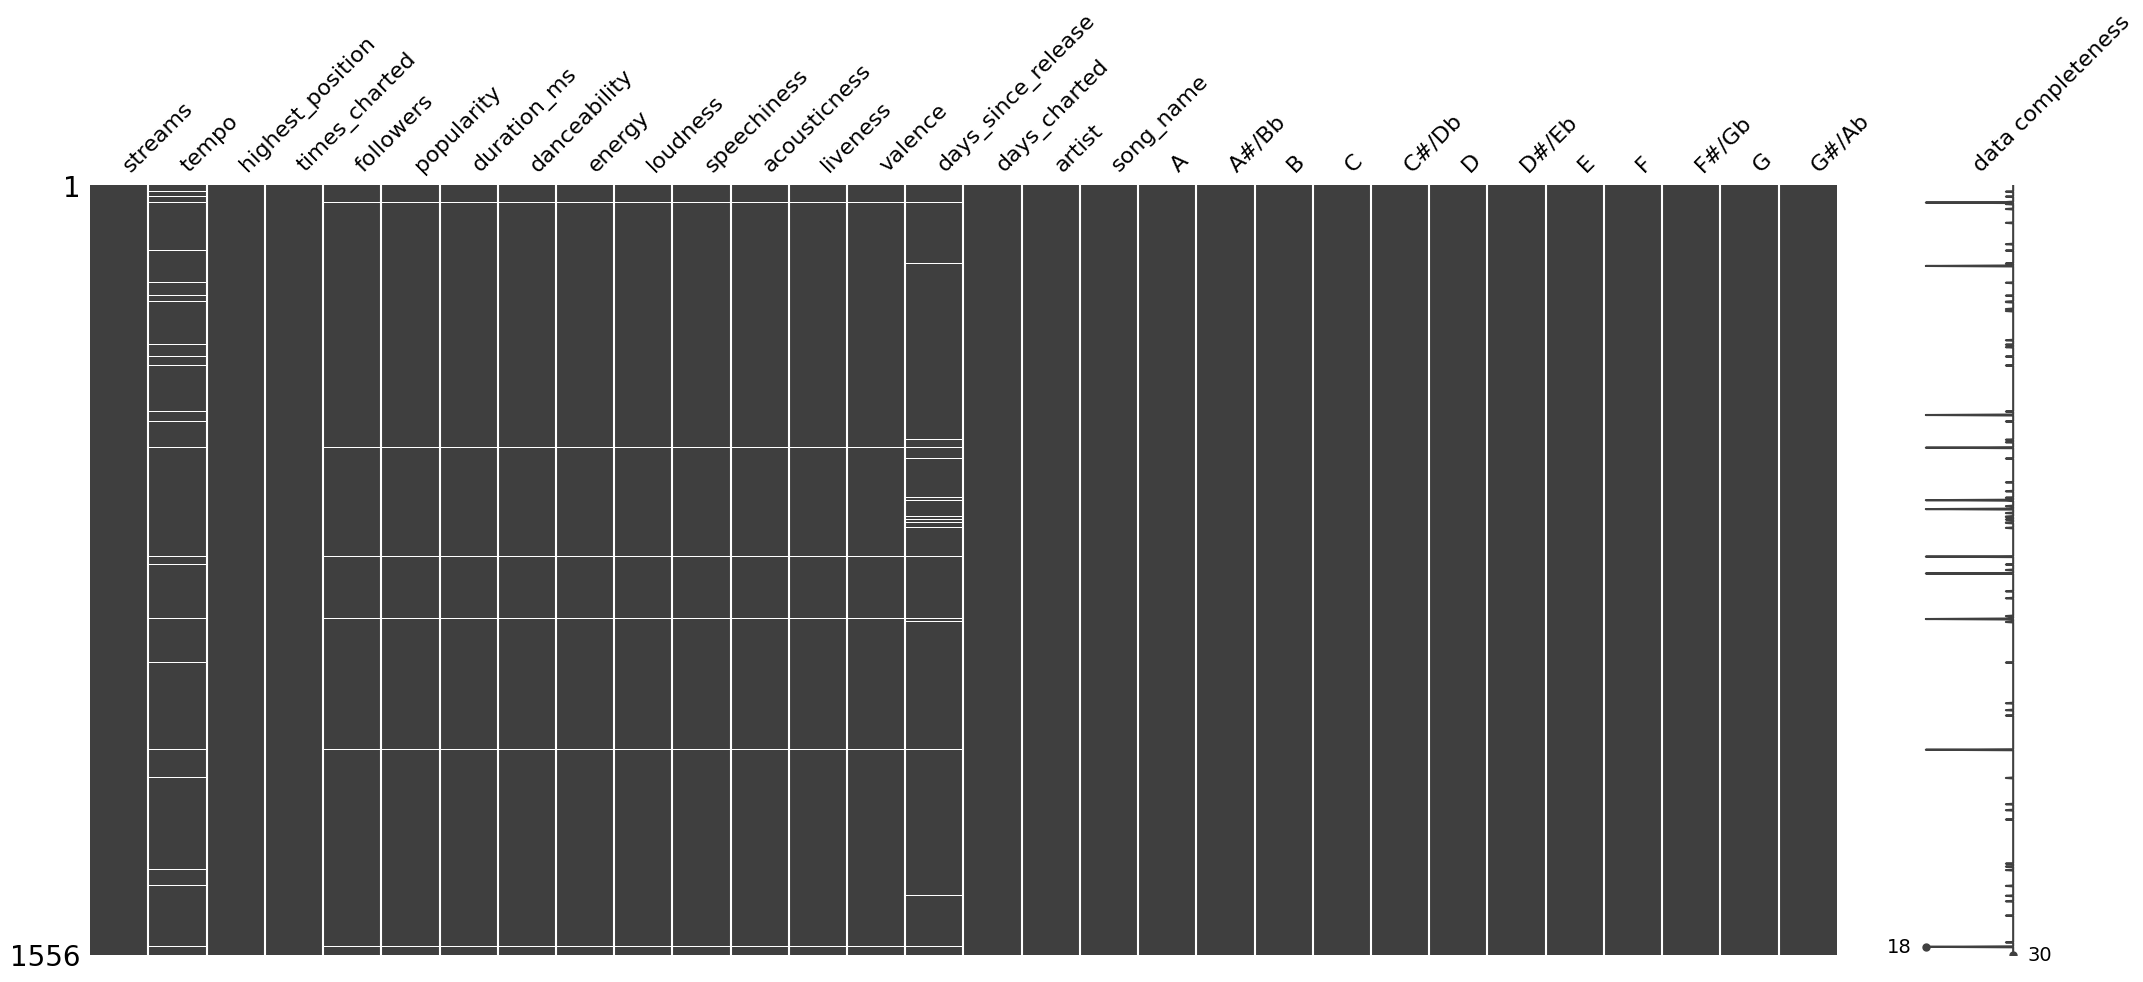

In [43]:
msno.matrix(miss_dat, labels=True)

* Dropping all `null` rows...

<Axes: >

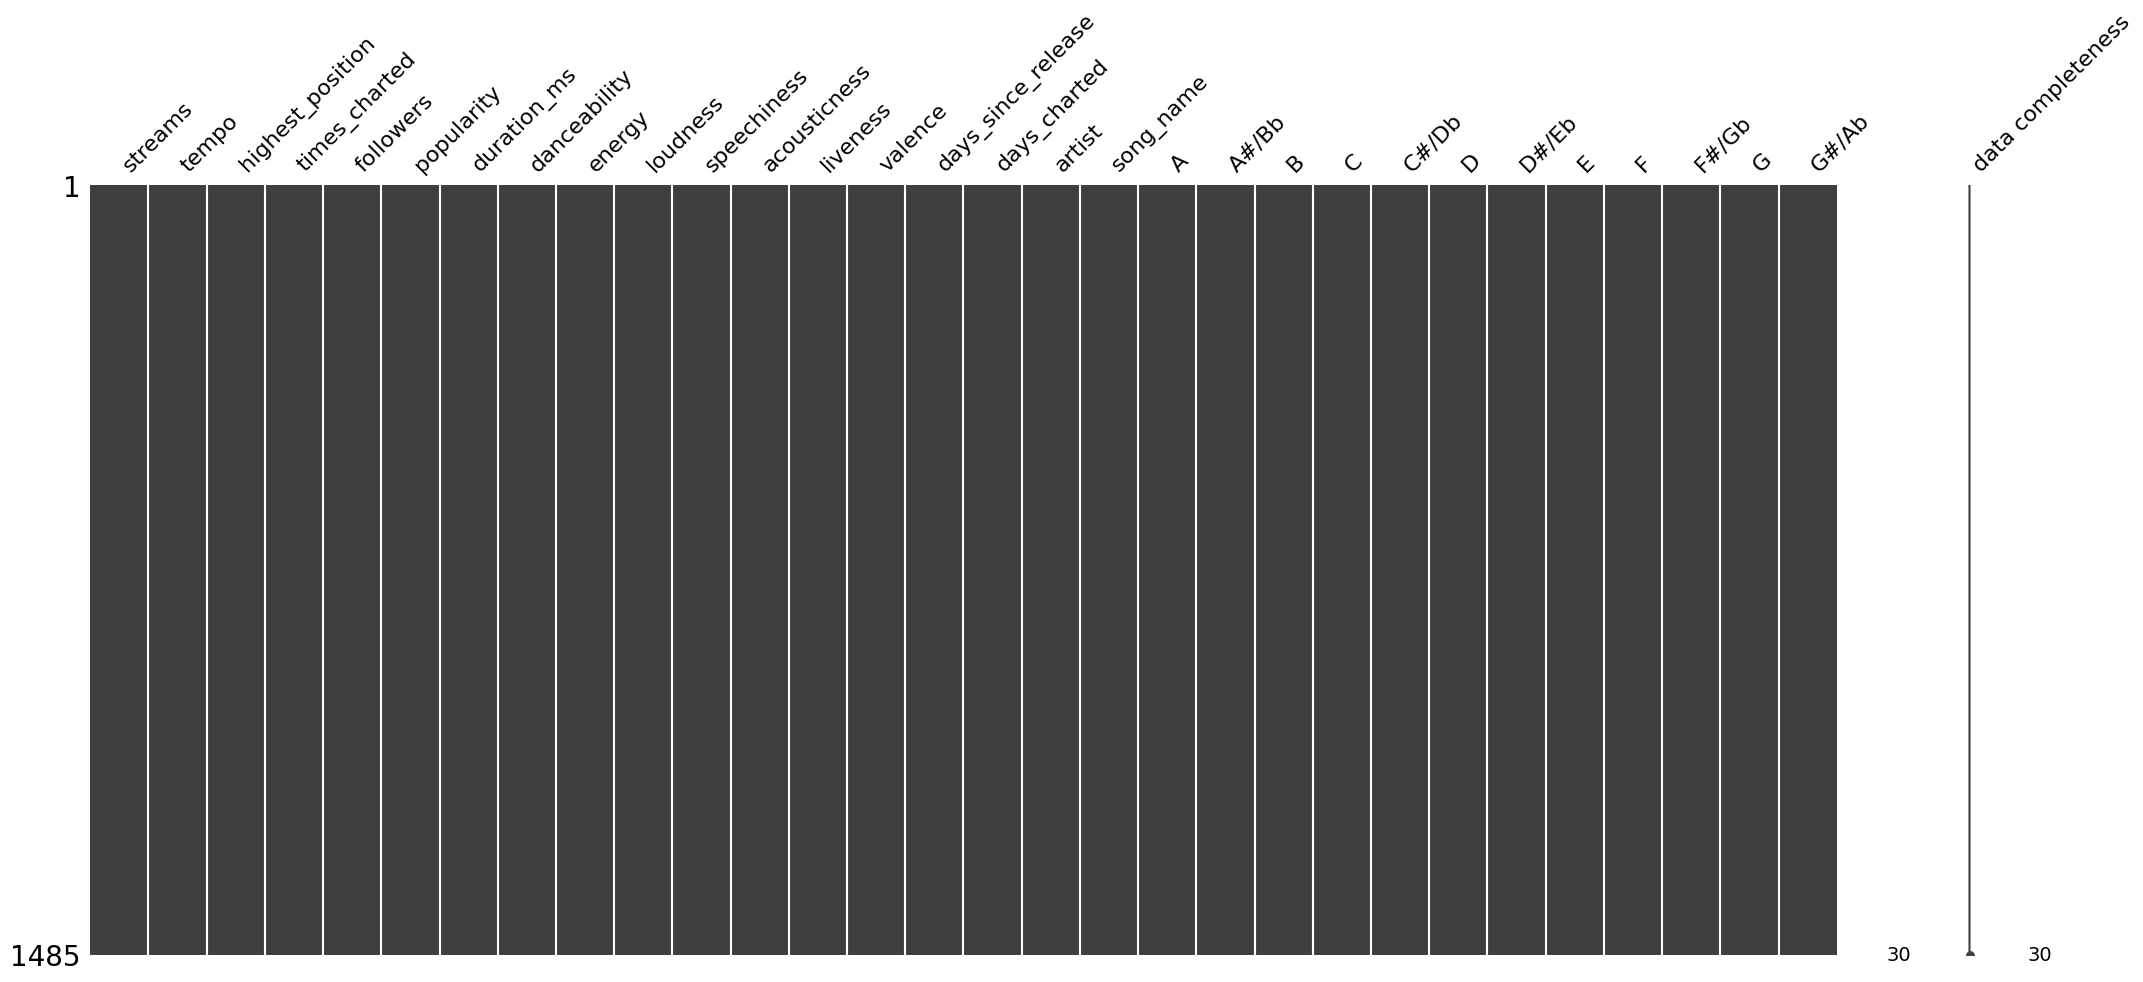

In [44]:
main_dat = miss_dat.dropna()
msno.matrix(main_dat, labels=True)

In [45]:
metadata(main_dat)

,Data_types,Count,Nulls,Nulls_pct,Memory,NUnique,NUnique_pct,count,unique,top,...,mean,std,min,Q1_25%,Q2_median,Q3_75%,max,IRQ,range,sum
streams,Int64,1485,0,0.0,13365,1485,100.0,1485,<NA>,<NA>,...,6325154.542761,3397195.501797,4214147.0,4913147.0,5260351.0,6426522.0,48633449.0,1513375.0,44419302.0,9392854496.0
tempo,Int64,1485,0,0.0,13365,331,22.3,1485,<NA>,<NA>,...,235.455892,266.594886,2.0,117.0,137.0,170.0,999.0,53.0,997.0,349652.0
highest_position,Int64,1485,0,0.0,13365,200,13.5,1485,<NA>,<NA>,...,87.438384,57.983033,1.0,38.0,80.0,135.0,200.0,97.0,199.0,129846.0
times_charted,Int64,1485,0,0.0,13365,75,5.1,1485,<NA>,<NA>,...,10.593939,16.268016,1.0,1.0,4.0,12.0,142.0,11.0,141.0,15732.0
followers,Int64,1485,0,0.0,13365,576,38.8,1485,<NA>,<NA>,...,14817943.546128,16679839.379291,4883.0,2110870.0,6930669.0,23848461.0,83337783.0,21737591.0,83332900.0,22004646166.0
popularity,Int64,1485,0,0.0,13365,67,4.5,1485,<NA>,<NA>,...,70.038384,15.869261,0.0,65.0,73.0,80.0,100.0,15.0,100.0,104007.0
duration_ms,Int64,1485,0,0.0,13365,1431,96.4,1485,<NA>,<NA>,...,197807.000673,46831.932895,30133.0,169266.0,193555.0,218802.0,588139.0,49536.0,558006.0,293743396.0
danceability,float64,1485,0,0.0,11880,523,35.2,1485,NaN,NaN,...,0.691656,0.142122,0.15,0.6,0.709,0.798,0.98,0.198,0.83,1027.109
energy,float64,1485,0,0.0,11880,562,37.8,1485,NaN,NaN,...,0.63452,0.159225,0.054,0.535,0.642,0.752,0.97,0.217,0.916,942.262
loudness,float64,1485,0,0.0,11880,1344,90.5,1485,NaN,NaN,...,-6.321406,2.456471,-25.166,-7.476,-5.988,-4.692,1.509,2.784,26.675,-9387.288


In [46]:
main_dat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1485 entries, 1 to 1556
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   streams             1485 non-null   Int64  
 1   tempo               1485 non-null   Int64  
 2   highest_position    1485 non-null   Int64  
 3   times_charted       1485 non-null   Int64  
 4   followers           1485 non-null   Int64  
 5   popularity          1485 non-null   Int64  
 6   duration_ms         1485 non-null   Int64  
 7   danceability        1485 non-null   float64
 8   energy              1485 non-null   float64
 9   loudness            1485 non-null   float64
 10  speechiness         1485 non-null   float64
 11  acousticness        1485 non-null   float64
 12  liveness            1485 non-null   float64
 13  valence             1485 non-null   float64
 14  days_since_release  1485 non-null   Int64  
 15  days_charted        1485 non-null   Int64  
 16  artist     

### Visualizations

#### Random Observations

* Which songs have a `Tempo` of 999???

In [47]:
false_temp = ( main_dat['tempo'] == 999 )
main_dat[false_temp]

,streams,tempo,highest_position,times_charted,followers,popularity,duration_ms,danceability,energy,loudness,...,B,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab
Index,,,,,,,,,,,,,,,,,,,,,
405,5026961,999,37,31,6929075,79,213314,0.823,0.821,-3.402,...,False,False,False,False,False,False,False,False,False,True
1050,5931242,999,121,1,6852509,61,192000,0.831,0.762,-5.656,...,True,False,False,False,False,False,False,False,False,False
1514,6483001,999,111,1,28931149,55,186459,0.724,0.415,-8.408,...,False,False,False,False,False,False,False,False,True,False


In [48]:
tempo_sorted = main_dat.sort_values(by="tempo", ascending=False)

subset = tempo_sorted.head(10)

fig_false_temp = px.line(
    subset,
    x="song_name",
    y="tempo",
    title="Top 10 Songs with Impossible BPM"
)

fig_false_temp.update_layout(
    yaxis_title = "Song Name",
    xaxis_title = "Tempo"
)

fig_false_temp.update_xaxes(tickangle=45)

fig_false_temp.show()

* Which songs had a #1 spot in the charts?

In [49]:
main_dat.columns

Index(['streams', 'tempo', 'highest_position', 'times_charted', 'followers',
       'popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'liveness', 'valence',
       'days_since_release', 'days_charted', 'artist', 'song_name', 'A',
       'A#/Bb', 'B', 'C', 'C#/Db', 'D', 'D#/Eb', 'E', 'F', 'F#/Gb', 'G',
       'G#/Ab'],
      dtype='object')

In [50]:
main_dat['days_charted'].sort_values(ascending=False)

,days_charted
Index,
369,994
93,588
80,581
66,581
100,581
...,...
1511,7
1512,7
1513,7


* What do the `Streams` and `Duration (ms)` variables look like when plotted?

In [51]:
fig_streams_duration = px.line(
    main_dat,
    x="streams",
    y="duration_ms",
    title="Song Duration (ms) vs. Total Streams"
    )

fig_streams_duration.update_layout(
    yaxis_title = "Duration (ms)",
    xaxis_title = "Total Streams"
)

fig_streams_duration.show()

* **Action:** Create a new column called `Duration (min)` for more intuitive reading.

* What does the relationship between number of `streams` and the number of `followers` an artist has look like?

In [52]:
fig_streams_followers = px.line(
    main_dat,
    x="streams",
    y="followers",
    title="Artist's Spotify Followers vs. Total Streams")

fig_streams_followers.update_layout(
    yaxis_title = "Followers",
    xaxis_title = "Total Streams"
)

fig_streams_followers.show()

#### Correlation Matrix

In [53]:
# remove objects
vars = main_dat.drop(columns=["artist", "song_name"])

In [54]:
# correlation plot
corr = vars.corr().round(2)
corr_fig = px.imshow(corr, color_continuous_scale='picnic', title="Possible Features: Correlation Matrix")
corr_fig.show()

* As expected, `times_charted` and `highest_position` are repetitive of `days_charted`. We remove those 2 columns.
* `loudness` and `acousticness` is also highly correlated with `energy`. I'm choosing to remove `energy` for interpretability and preference.

In [55]:
# drop highly correlated features and target var
features = main_dat.drop(columns=["artist", "song_name", "energy", "highest_position", "times_charted", "days_charted", "popularity", "streams"])

In [56]:
corr = features.corr().round(2)
corr_fig = px.imshow(corr, color_continuous_scale='picnic', title="Selected Features: Correlation Matrix")
corr_fig.show()

## First Model

In [57]:
features

,tempo,followers,duration_ms,danceability,loudness,speechiness,acousticness,liveness,valence,days_since_release,...,B,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab
Index,,,,,,,,,,,,,,,,,,,,,
1,134,3377762,211560,0.714,-4.808,0.0504,0.12700,0.3590,0.589,3091,...,True,False,False,False,False,False,False,False,False,False
2,169,2230022,141806,0.591,-5.484,0.0483,0.03830,0.1030,0.478,1782,...,False,False,True,False,False,False,False,False,False,False
3,166,6266514,178147,0.563,-5.044,0.1540,0.33500,0.0849,0.688,1831,...,False,False,False,False,False,False,False,False,False,False
4,126,83293380,231041,0.808,-3.712,0.0348,0.04690,0.3640,0.591,1796,...,True,False,False,False,False,False,False,False,False,False
5,149,5473565,212000,0.736,-7.409,0.0615,0.02030,0.0501,0.894,1768,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,116,27167675,209320,0.762,-6.021,0.0694,0.00261,0.1530,0.608,3280,...,False,False,False,False,False,False,False,False,False,False
1553,152,15019109,181930,0.528,-3.123,0.0851,0.24000,0.3330,0.714,2419,...,True,False,False,False,False,False,False,False,False,False
1554,104,22698747,217307,0.765,-4.333,0.0300,0.18400,0.1320,0.394,3056,...,False,False,False,True,False,False,False,False,False,False


In [58]:
X = features
y = main_dat['days_charted']

numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 113610.0


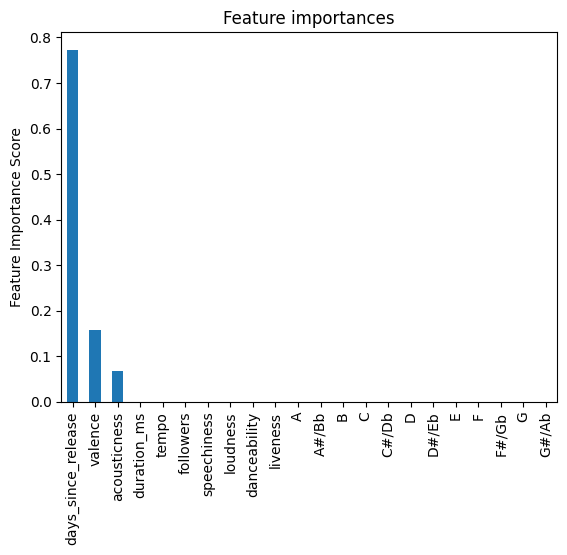

In [59]:
importances = model.feature_importances_
tree_importances = pd.Series( importances, index = X.columns )

plt.figure()
# tree_importances.plot.bar()
tree_importances.sort_values( ascending = False ).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score') ;

In [60]:
( tree_importances.sort_values( ascending = False ) * 100 ).cumsum()

,0
days_since_release,77.274513
valence,93.114140
acousticness,100.000000
duration_ms,100.000000
tempo,100.000000
followers,100.000000
speechiness,100.000000
loudness,100.000000
danceability,100.000000
liveness,100.000000


In [61]:
fig = px.histogram(main_dat, x="days_charted")
fig.show()

In [62]:
main_dat.sort_values(by='days_charted', ascending=False)

,streams,tempo,highest_position,times_charted,followers,popularity,duration_ms,danceability,energy,loudness,...,B,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab
Index,,,,,,,,,,,,,,,,,,,,,
369,5294368,110,5,142,16112621,83,240133,0.567,0.267,-6.502,...,False,False,False,False,False,True,False,False,False,False
93,7156162,120,6,84,33651775,87,215280,0.695,0.762,-3.497,...,False,True,False,False,False,False,False,False,False,False
80,7687058,27,1,83,2819593,83,209438,0.824,0.588,-6.400,...,False,False,False,False,False,False,False,True,False,False
66,8821971,123,2,83,1250353,0,183290,0.793,0.793,-4.521,...,True,False,False,False,False,False,False,False,False,False
100,6813800,111,22,83,8384096,83,215107,0.459,0.575,-4.858,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,7531094,100,87,1,28931149,55,192172,0.695,0.573,-8.882,...,False,False,False,False,False,False,False,False,False,False
1512,7394604,111,90,1,28931149,56,170498,0.784,0.552,-7.261,...,False,False,True,False,False,False,False,False,False,False
1513,6693229,110,107,1,28931149,55,148776,0.873,0.510,-5.350,...,False,False,False,False,True,False,False,False,False,False


## Revisions

Things not previously checked:
1. **Duplicates** - these can add weight to the decision tree. For example, `followers` shows duplicates since they refer to the artist, not the song.
  * **Solution**: Drop columns where strong duplicates occur.
2. **Distribution** - outliers are certainly included in this set, as evidenced earlier by the `tempo` chart. The target variable, `days_charted`, is also *extremely* right-skewed.
  * **Solution**: `log` transform where appropriate.

* We can confirm, however, that `popularity` is ***not*** the most reliable "success" metric, given that songs who charted the longest weren't even in the Top 10 most popular ranks.

#### Duplicates

In [63]:
for col in features:
  duplicate_count = features[col].duplicated().sum()
  total_rows = 1485
  percent_dups = ( duplicate_count / total_rows ) * 100

  print(f"Duplicates in {col}: {duplicate_count}, or {percent_dups.round(2)}%")

Duplicates in tempo: 1154, or 77.71%
Duplicates in followers: 909, or 61.21%
Duplicates in duration_ms: 54, or 3.64%
Duplicates in danceability: 962, or 64.78%
Duplicates in loudness: 141, or 9.49%
Duplicates in speechiness: 727, or 48.96%
Duplicates in acousticness: 543, or 36.57%
Duplicates in liveness: 892, or 60.07%
Duplicates in valence: 765, or 51.52%
Duplicates in days_since_release: 1027, or 69.16%
Duplicates in A: 1483, or 99.87%
Duplicates in A#/Bb: 1483, or 99.87%
Duplicates in B: 1483, or 99.87%
Duplicates in C: 1483, or 99.87%
Duplicates in C#/Db: 1483, or 99.87%
Duplicates in D: 1483, or 99.87%
Duplicates in D#/Eb: 1483, or 99.87%
Duplicates in E: 1483, or 99.87%
Duplicates in F: 1483, or 99.87%
Duplicates in F#/Gb: 1483, or 99.87%
Duplicates in G: 1483, or 99.87%
Duplicates in G#/Ab: 1483, or 99.87%


* The chords are binary, so these are being ignored for now.
* Opting to drop columns with more than 70% dups...
* And another set of 60%+ ...

In [64]:
features2 = features.drop(columns=['tempo', 'days_since_release'])
features3 = features2.drop(columns=['followers', 'danceability', 'liveness'])

#### Distribution

In [65]:
fig = px.histogram(main_dat, x="tempo")
fig.show()

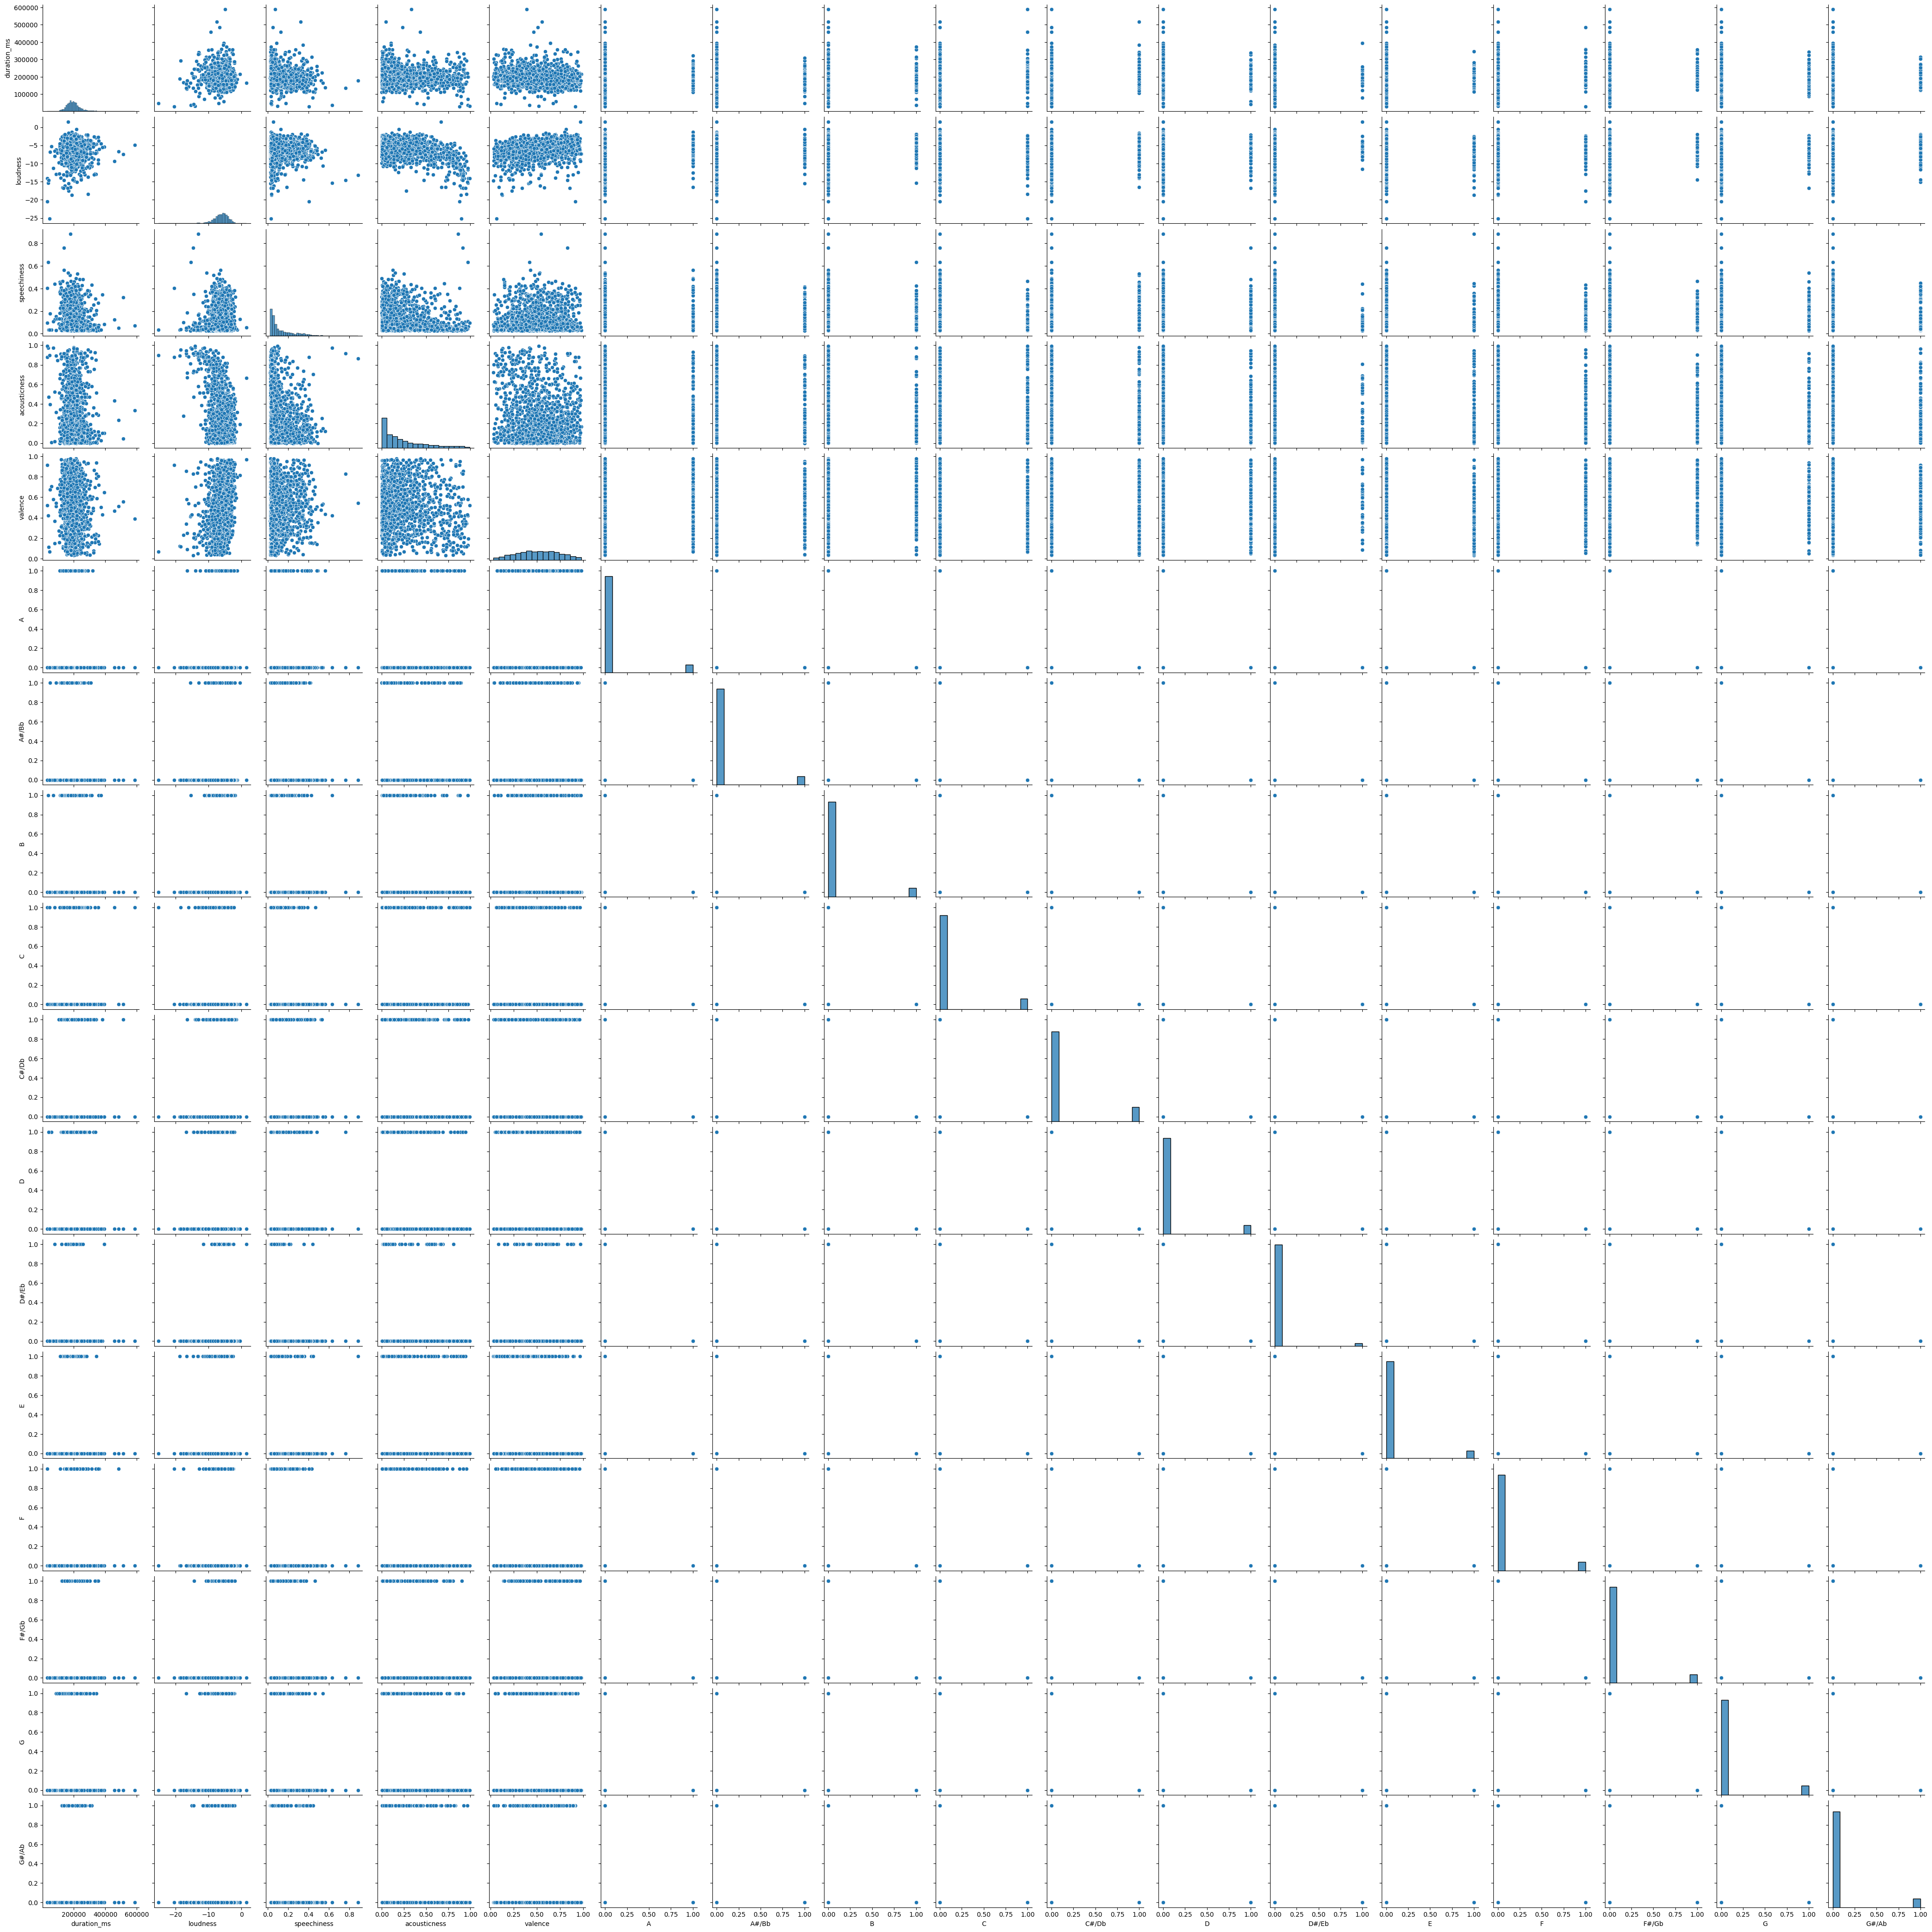

In [66]:
import seaborn as sns

sns.pairplot(features3) ;

#### Log-Transformations

In [67]:
main_dat['days_charted_log'] = np.log1p(main_dat['days_charted'])
main_dat

/tmp/ipykernel_3891/3279324649.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,streams,tempo,highest_position,times_charted,followers,popularity,duration_ms,danceability,energy,loudness,...,C,C#/Db,D,D#/Eb,E,F,F#/Gb,G,G#/Ab,days_charted_log
Index,,,,,,,,,,,,,,,,,,,,,
1,48633449,134,1,8,3377762,100,211560,0.714,0.800,-4.808,...,False,False,False,False,False,False,False,False,False,4.043051
2,47248719,169,2,3,2230022,99,141806,0.591,0.764,-5.484,...,False,True,False,False,False,False,False,False,False,3.091042
3,40162559,166,1,11,6266514,99,178147,0.563,0.664,-5.044,...,False,False,False,False,False,False,False,False,False,4.356709
4,37799456,126,3,5,83293380,98,231041,0.808,0.897,-3.712,...,False,False,False,False,False,False,False,False,False,3.583519
5,33948454,149,5,1,5473565,96,212000,0.736,0.704,-7.409,...,False,False,False,True,False,False,False,False,False,2.079442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,4630675,116,195,1,27167675,79,209320,0.762,0.700,-6.021,...,False,False,False,False,False,False,False,False,False,2.079442
1553,4623030,152,196,1,15019109,66,181930,0.528,0.870,-3.123,...,False,False,False,False,False,False,False,False,False,2.079442
1554,4620876,104,197,1,22698747,81,217307,0.765,0.523,-4.333,...,False,False,True,False,False,False,False,False,False,2.079442


In [68]:
fig = px.histogram(main_dat, x="days_charted_log")
fig.show()

## Second Model

In [69]:
X = features2
y = main_dat['days_charted_log']

numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 1290.0


* This time, we optimize the ideal depth using loops.

In [70]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std( ddof = 1 )

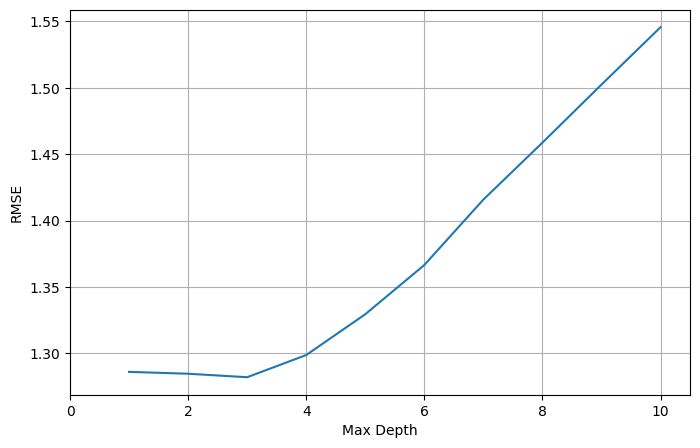

In [71]:
# Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

## Third Model

In [72]:
X_3 = features3
y_3 = main_dat['days_charted_log']

numLoops_3 = 500

rms_error_3 = np.zeros(numLoops_3)

for idx_3 in range(0,numLoops_3):
  X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3,y_3,test_size=0.2)
  model_3 = DecisionTreeRegressor(max_depth=2)         # Arbitrarily choosing max_depth of 3
  model_3.fit(X_train_3,y_train_3)
  y_pred_3 = model_3.predict(X_test_3)
  rms_error_3[idx_3] = np.sqrt(mean_squared_error(y_test_3, y_pred_3))

print(f"CV RMSE: {rms_error_3.mean().round(2)*1000}")

CV RMSE: 1280.0


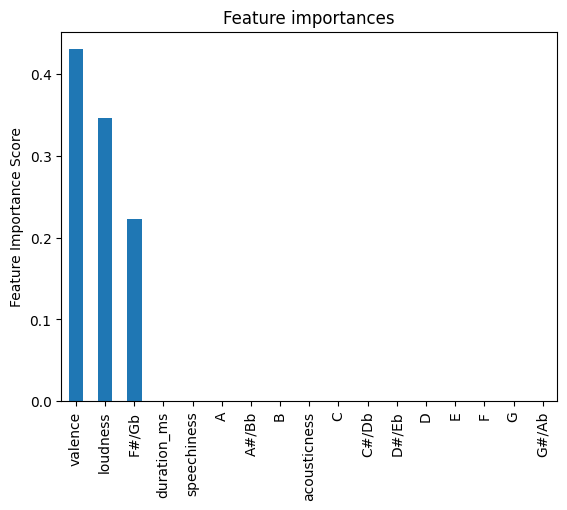

In [73]:
importances_3 = model_3.feature_importances_
tree_importances_3 = pd.Series( importances_3, index = X_3.columns )

plt.figure()
# tree_importances.plot.bar()
tree_importances_3.sort_values( ascending = False ).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score') ;

## Future Development

* Revise the helper functions and import from GitHub
* Feature transformation and optimization
* Different target variable